# University of Chicago
### DATA 25900: Ethics, Fairness, Responsibility, and Privacy in Data Science, Spring 2023
#### Course Staff: Satadisha Saha Bhowmick, Victor Brown, Jihee You

# Assignment 0: Introduction

## 0. Resources to Start with Python

This is a list of resources with exercises that should help you refresh your programming skills in Python, the language we use in the class. Following and working through these exercises should feel comfortable, almost easy. If it is too hard, then you should consider getting up to speed ASAP so that your programming skills do not get in the way of complementing the programming assignments.

To start, this is a list of resources you should read

0. Get familiar with VSCode and Jupyter Notebook, so that you can download the assignment and work on it from your local Python environment. **We strongly recommend using VSCode since it will be a one-stop portal for you to develop your code and then export your notebook to a PDF for submission purposes**.

1. Python has its own [official tutorial](https://docs.python.org/3/tutorial/index.html). Some other resources that might be easier for starters include: [TutorialsPoint](https://www.tutorialspoint.com/python/index.htm), [W3Schools](https://www.w3schools.com/python/python_intro.asp). For the tasks below, you probably need to know following things:
    * Basic Syntax of Python
    * Data Types (including list, tuple, dictionary)
    * If...else
    * Loops
    * Functions
    
2. A lot of interesting functionality (hypothesis testing, inferential stats, machine learning, and many more) are already available via [libraries](https://en.wikipedia.org/wiki/Library_(computing)). Libraries are available in the Internet. You can install libraries in your environment to use them in your programs. You can use `pip` to install and manage all the packages you need. You can find the documentation [here](https://pip.pypa.io/en/stable/). If you are using Colab, many common libraries that are needed for the assignments are already pre-installed. If you need any other library, read this [page](https://colab.research.google.com/notebooks/snippets/importing_libraries.ipynb) on how to install libraries in Colab.

3. For data analysis, we will use a lot of a library called `pandas`. Its official documentation is [here](https://pandas.pydata.org/docs/). The [User Guide](https://pandas.pydata.org/docs/user_guide/index.html#user-guide) might be a good place to start.

4. For visualization, `pandas` has built-in visualization APIs, but you should become familiar with others. We recommend knowing `matplotlib` so you can do more advanced visualization. The documentation for matplotlib is [here](https://matplotlib.org/stable/users/index.html#).

5. For statistical analysis, here is some potential resources if you have never taken a statistic class before:
    * [A Gentle Introduction to Statistical Hypothesis Testing](https://machinelearningmastery.com/statistical-hypothesis-tests/) by Jason Brownlee

6. To do basic statistical analysis in Python, `scipy` is what most people would go to. You don't have to read the documentation thoroughly. Use it by searching based on needs should be enough.


## 0.1 Seeking Help

A key goal of this class is that you hone your programming skills. This not only means you become more proficient with Python and data analysis, but that you also become more resourceful to solve the problems you inevitably will find. Computer Science is a great community of researchers, practitioners, and aficionados who all together have been creating and publishing great content, mostly for free, for years. When you have a programming question that you do not know how to solve, you should leverage search engines and resources such as Stackoverflow to guide you to the solution. Of course, for these resources to be helpful, you need to ask the right question. Questions are good when they are concrete. For example, if I didn't know how to run a chi-square hypothesis test on some data, I could go to e.g., Google and write:

*chi-square on two columns python*

The first result points to stackoverflow, [here](https://codereview.stackexchange.com/questions/96761/chi-square-independence-test-for-two-pandas-df-columns), which contains both the original question (that matches ours) and a few answers.

As with any information coming from the outside world, you should scrutinize it carefully. You probably don't want to just copy-paste code. You want to make sure the question asked and yours match. If they do, then you want to ensure that the solution makes sense. Finally, you may want to consider the best way of incorporating the solution into your own program. As a general rule, if you don't fully understand what the solution does, then you should not use it. This is common sense, and yet, one of the main sources of pitfalls and problems in data analysis out there. Be responsible and own your work.

## 0.2 Deliverables

For each question, you may need to write Python code to do data analysis, provide only an explanation in prose, or do both. Use the *Code* block for any code you write in solving the problem, and use the *Markdown* block for your explanation of what you did. We have included one Code block for each question, but feel free to add more Code or Markdown blocks as you see fit. In general, within the Markdown block you should explain the approach you took in your code at a high level in addition to explicitly answering any questions that were asked. It is up to you to decide what code-based analyses, if any, are appropriate for a particular problem.


## 1. Load Data

To start with, please use pandas to load the file `confirmed_US.csv` as a dataframe. The is data about COVID cases in early 2020.

Some context on the data:

* **Lat:** Latitude
* **Long:** Longitude
* **Location:** The name of the location where the number of cases are reported.
* **1/22/2020, ..., 3/29/2020:** By the day indicated by the column name, how many cases have been reported in the location.

Note: if your dataframe is called `df`, you can simply display the dataframe by running the line `df` or `df.head(n)` with `n` being the number of rows you want to display.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
DATA_DIR = '/Users/joycezhang/Downloads/Data259/PA0/'

In [2]:
covid_df = pd.read_csv(DATA_DIR + 'confirmed_US.csv')
covid_df.head()

,Lat,Long,Location,1/22/2020,1/23/2020,1/24/2020,1/25/2020,1/26/2020,1/27/2020,1/28/2020,...,3/19/2020,3/20/2020,3/21/2020,3/23/2020,3/24/2020,3/25/2020,3/26/2020,3/27/2020,3/28/2020,3/29/2020
0,NaN,NaN,"Unassigned, Alabama, US",0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,NaN,NaN,"Unassigned, Alaska, US",0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,NaN,NaN,"Unassigned, Arizona, US",0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,NaN,NaN,"Unassigned, Arkansas, US",0,0,0,0,0,0,0,...,58,96,118,3,13,20,24,35,32,31
4,NaN,NaN,"Unassigned, California, US",0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,12,0,0


In [3]:
covid_df['Location'] = covid_df['Location'].apply(str)

## 2. Basic Analysis

1. The location of reported cases are in a combined string right now. To make analysis easier, please create a column for counties and another column for states.

    Please be aware that there will be special cases in the dataset, such as Diamond Princess, etc. The location that doesn't have a county will be regarded as a state and a `None` should be placed as its county.

In [4]:
def get_county_state(location_str):
    # you may find it helpful to create a function that extracts county and state (and deal with special cases) from a location string
    separated_str = [item.strip() for item in location_str.split(',')]
    if len(separated_str) > 2:
        county = separated_str[0]
        state =  separated_str[1]
    else:
        county = None
        state = separated_str[0]
    return [county, state]

In [5]:
covid_df[['County', 'State']] = covid_df['Location'].apply(get_county_state).apply(pd.Series)

In [6]:
covid_df.head()

,Lat,Long,Location,1/22/2020,1/23/2020,1/24/2020,1/25/2020,1/26/2020,1/27/2020,1/28/2020,...,3/21/2020,3/23/2020,3/24/2020,3/25/2020,3/26/2020,3/27/2020,3/28/2020,3/29/2020,County,State
0,NaN,NaN,"Unassigned, Alabama, US",0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Unassigned,Alabama
1,NaN,NaN,"Unassigned, Alaska, US",0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Unassigned,Alaska
2,NaN,NaN,"Unassigned, Arizona, US",0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Unassigned,Arizona
3,NaN,NaN,"Unassigned, Arkansas, US",0,0,0,0,0,0,0,...,118,3,13,20,24,35,32,31,Unassigned,Arkansas
4,NaN,NaN,"Unassigned, California, US",0,0,0,0,0,0,0,...,0,0,0,0,0,12,0,0,Unassigned,California


2. Please select all the rows where the state is Illinois and sort the rows based on the number of confirmed cases on 3/29/2020 from the most to the least.

In [7]:
IL_df = covid_df[covid_df['State']=='Illinois'].copy().sort_values(by='3/29/2020', ascending=False)
IL_df = IL_df.drop(IL_df.columns[:3], axis=1)
IL_df

,1/22/2020,1/23/2020,1/24/2020,1/25/2020,1/26/2020,1/27/2020,1/28/2020,1/29/2020,1/30/2020,1/31/2020,...,3/21/2020,3/23/2020,3/24/2020,3/25/2020,3/26/2020,3/27/2020,3/28/2020,3/29/2020,County,State
661,0,0,1,1,1,1,1,1,1,2,...,548,922,1194,1418,1418,2239,2613,3445,Cook,Illinois
694,0,0,0,0,0,0,0,0,0,0,...,63,96,111,139,139,230,241,300,Lake,Illinois
667,0,0,0,0,0,0,0,0,0,0,...,65,95,103,131,131,199,202,274,DuPage,Illinois
744,0,0,0,0,0,0,0,0,0,0,...,12,24,28,40,40,104,127,182,Will,Illinois
690,0,0,0,0,0,0,0,0,0,0,...,8,18,24,38,38,75,90,100,Kane,Illinois
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
706,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Marion,Illinois
669,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Edwards,Illinois
709,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Massac,Illinois
711,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Mercer,Illinois


3. Which county in Illinois is the 10th county with the most cases by 3/29/2020? How many cases were there on 3/29/2020?

In [8]:
IL_df.set_index('County', inplace=True)
cols = IL_df.columns.values[:-1]
IL_df = IL_df[cols].cumsum(axis=1)
IL_df.head(10)

,1/22/2020,1/23/2020,1/24/2020,1/25/2020,1/26/2020,1/27/2020,1/28/2020,1/29/2020,1/30/2020,1/31/2020,...,3/19/2020,3/20/2020,3/21/2020,3/23/2020,3/24/2020,3/25/2020,3/26/2020,3/27/2020,3/28/2020,3/29/2020
County,,,,,,,,,,,,,,,,,,,,,
Cook,0,0,1,2,3,4,5,6,7,9,...,937,1215,1763,2685,3879,5297,6715,8954,11567,15012
Lake,0,0,0,0,0,0,0,0,0,0,...,76,113,176,272,383,522,661,891,1132,1432
DuPage,0,0,0,0,0,0,0,0,0,0,...,128,182,247,342,445,576,707,906,1108,1382
Will,0,0,0,0,0,0,0,0,0,0,...,15,24,36,60,88,128,168,272,399,581
Kane,0,0,0,0,0,0,0,0,0,0,...,29,35,43,61,85,123,161,236,326,426
McHenry,0,0,0,0,0,0,0,0,0,0,...,23,29,40,52,66,85,104,149,196,248
Kankakee,0,0,0,0,0,0,0,0,0,0,...,1,2,4,7,11,17,23,40,67,100
St. Clair,0,0,0,0,0,0,0,0,0,0,...,16,19,22,26,33,40,47,62,80,111
Champaign,0,0,0,0,0,0,0,0,0,0,...,4,5,8,11,15,19,29,39,50,71


Kendall county had the 10th most cases by March 29th 2020. There were 15 cases on March 29th 2020. 

4. Please load data from `states_population_2019.csv` and assume the population doesn't change since then. Then, the population data should be joined to the dataframe you got in Question 1 based on `State` as a new column called `State Population`. If you have never taken a Database class before, [the link here](https://en.wikipedia.org/wiki/Relational_algebra#Joins_and_join-like_operators) will help you understand what "join" means.

    For rows where the data in `State` is not actually a state (e.g. Diamond Princess), feel free to just leave it with a `NaN`.

In [9]:
pop_df = pd.read_csv(DATA_DIR + 'states_population_2019.csv')
joined_df = pd.merge(covid_df, pop_df, on='State', how='left')
print(joined_df.shape) #ensure we are merging correctly :D
joined_df.head()

(3205, 73)


,Lat,Long,Location,1/22/2020,1/23/2020,1/24/2020,1/25/2020,1/26/2020,1/27/2020,1/28/2020,...,3/23/2020,3/24/2020,3/25/2020,3/26/2020,3/27/2020,3/28/2020,3/29/2020,County,State,Population
0,NaN,NaN,"Unassigned, Alabama, US",0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,Unassigned,Alabama,4903185.0
1,NaN,NaN,"Unassigned, Alaska, US",0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,Unassigned,Alaska,731545.0
2,NaN,NaN,"Unassigned, Arizona, US",0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,Unassigned,Arizona,7278717.0
3,NaN,NaN,"Unassigned, Arkansas, US",0,0,0,0,0,0,0,...,3,13,20,24,35,32,31,Unassigned,Arkansas,3017825.0
4,NaN,NaN,"Unassigned, California, US",0,0,0,0,0,0,0,...,0,0,0,0,12,0,0,Unassigned,California,39512223.0


5. What are the top 5 states in the US that have the most confirmed cases by 3/29/2020?

In [10]:
joined_df['cum_sum'] = joined_df.iloc[:, 3:-3].sum(axis=1)
joined_df.head()

,Lat,Long,Location,1/22/2020,1/23/2020,1/24/2020,1/25/2020,1/26/2020,1/27/2020,1/28/2020,...,3/24/2020,3/25/2020,3/26/2020,3/27/2020,3/28/2020,3/29/2020,County,State,Population,cum_sum
0,NaN,NaN,"Unassigned, Alabama, US",0,0,0,0,0,0,0,...,0,0,0,0,0,0,Unassigned,Alabama,4903185.0,4
1,NaN,NaN,"Unassigned, Alaska, US",0,0,0,0,0,0,0,...,0,0,0,0,0,0,Unassigned,Alaska,731545.0,1
2,NaN,NaN,"Unassigned, Arizona, US",0,0,0,0,0,0,0,...,0,0,0,0,0,0,Unassigned,Arizona,7278717.0,0
3,NaN,NaN,"Unassigned, Arkansas, US",0,0,0,0,0,0,0,...,13,20,24,35,32,31,Unassigned,Arkansas,3017825.0,448
4,NaN,NaN,"Unassigned, California, US",0,0,0,0,0,0,0,...,0,0,0,12,0,0,Unassigned,California,39512223.0,13


In [11]:
state_df = joined_df.groupby('State')['cum_sum'].sum().sort_values(ascending=False)
state_df.head()

State
New York      287866
New Jersey     55188
California     35173
Washington     33104
Michigan       23549
Name: cum_sum, dtype: int64

Top 5 states are New York, New Jersey, Washington, California, and Illinois.

6. For each state in the US, display the county that has the most confirmed cases by 3/29/2020?

In [12]:
top_county = joined_df.groupby(['State', 'County'])['cum_sum'].sum().reset_index()
top_county.loc[top_county.groupby('State')['cum_sum'].idxmax()]

,State,County,cum_sum
36,Alabama,Jefferson,1297
70,Alaska,Anchorage,220
105,Arizona,Maricopa,2486
173,Arkansas,Pulaski,559
208,California,Los Angeles,9577
265,Colorado,Denver,2151
314,Connecticut,Fairfield,5249
324,Delaware,New Castle,796
327,District of Columbia,District of Columbia,1819
371,Florida,Miami-Dade,4912


---

Starting from here, we will ask you to make some visualizations (plots). For **all** the figures below, please include a title of the figure, and name both the x-axis and the y-axis. All the labels on the x-axis and the y-axis should be readable (i.e. no overlaps).

---


7. Please create a line plot to show how the cumulative number of confirmed cases changed in the US through time.

In [13]:
cum_sum = covid_df.iloc[:, 3:-2].sum().cumsum().tolist()
cum_sum


[1,
 2,
 4,
 6,
 11,
 16,
 21,
 26,
 31,
 38,
 46,
 54,
 65,
 76,
 87,
 98,
 109,
 120,
 131,
 142,
 154,
 166,
 179,
 192,
 205,
 218,
 231,
 244,
 257,
 270,
 285,
 300,
 315,
 330,
 345,
 360,
 376,
 392,
 416,
 446,
 499,
 572,
 676,
 848,
 1065,
 1401,
 1851,
 2365,
 3073,
 4178,
 5735,
 7882,
 10739,
 13657,
 17964,
 24060,
 31062,
 41132,
 55211,
 73307,
 116971,
 170709,
 236490,
 320329,
 421990,
 543476,
 684370]

Text(0, 0.5, 'Count (Thousands)')

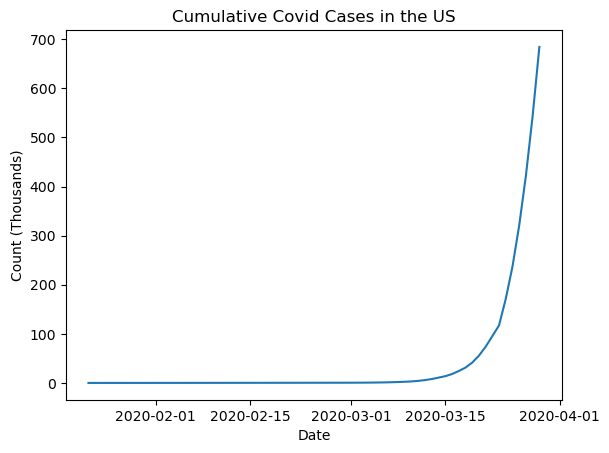

In [14]:
y = [x/1000 for x in cum_sum]
date_columns = covid_df.columns.values[3:-2].copy()
date_columns = pd.to_datetime(covid_df.columns.values[3:-2])
plt.plot(date_columns, y)
plt.title('Cumulative Covid Cases in the US')
plt.xlabel('Date')
plt.ylabel('Count (Thousands)')

8. What if we put the y-axis in the above figure to log?

Text(0, 0.5, 'Cumulative Count (log)')

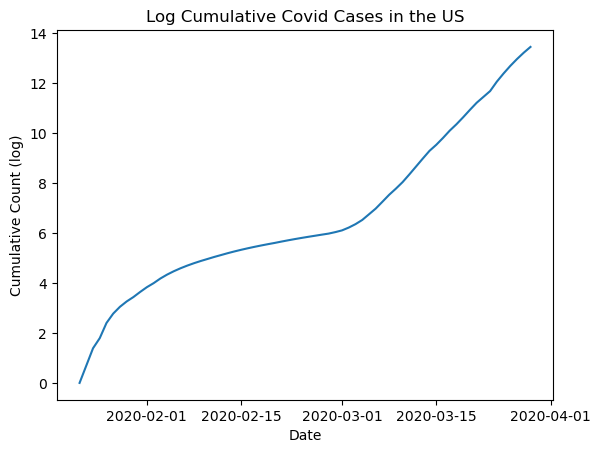

In [15]:
cum_sum_log = [np.log(x) for x in cum_sum]
plt.plot(date_columns, cum_sum_log)
plt.title('Log Cumulative Covid Cases in the US')
plt.xlabel('Date')
plt.ylabel('Cumulative Count (log)')

9. Please create a bar plot to display the states in the US that have the ten highest densities of confirmed cases by 3/29/2020.

In [16]:
density_df = pd.merge(state_df, pop_df, on='State', how='inner')
density_df['Density'] = density_df['cum_sum']/density_df['Population']*100
top_10_density = density_df[['Density', 'State']].sort_values(by='Density', ascending=False).head(10)
top_10_density

,Density,State
0,1.479760,New York
1,0.621333,New Jersey
3,0.434727,Washington
8,0.403008,Louisiana
5,0.306828,Massachusetts
33,0.257740,District of Columbia
14,0.239728,Connecticut
4,0.235800,Michigan
52,0.215426,Guam
40,0.198401,Vermont


Text(0, 0.5, 'Density (percent/100)')

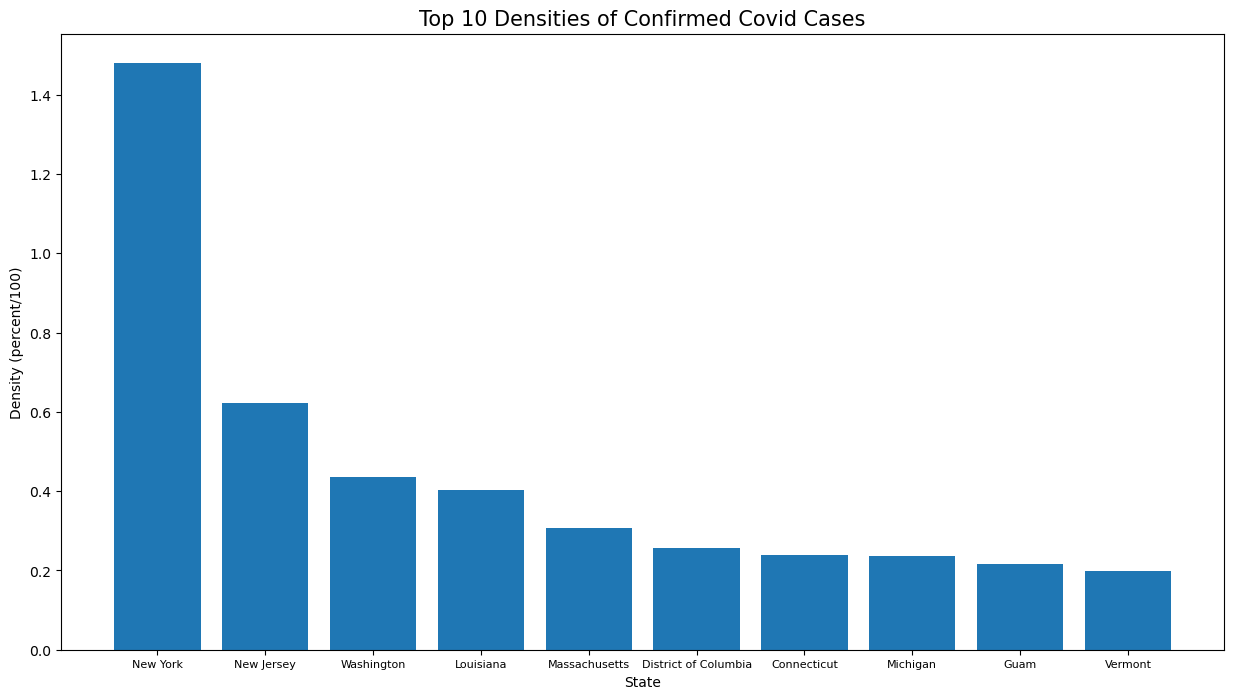

In [17]:
#bar plot
plt.figure(figsize=(15,8))
plt.bar(x='State', height='Density', data=top_10_density)
plt.title('Top 10 Densities of Confirmed Covid Cases', fontsize=15)
plt.xlabel('State')
plt.xticks(fontsize=8)
plt.ylabel('Density (percent/100)')

10. Please create a line plot to show the increase of confirmed cases for each day in the US.

Text(0, 0.5, 'Count (Thousands)')

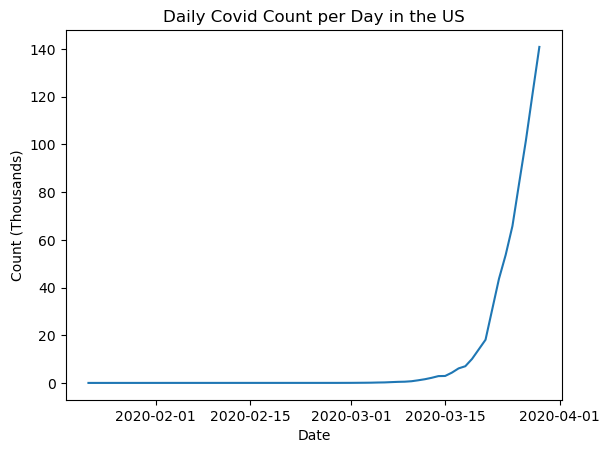

In [18]:
daily_counts = [cum_sum[0]] + [cum_sum[i] - cum_sum[i-1] for i in range(1, len(cum_sum))]
y = [x/1000 for x in daily_counts]
plt.plot(date_columns, y)
plt.title('Daily Covid Count per Day in the US')
plt.xlabel('Date')
plt.ylabel('Count (Thousands)')

11. Please create a line plot to show the increase of confirmed cases for each week in the US. You can use the increase between 1/22 and 1/29 as the starting point and 1/29-2/5 as the next.

    Please make sure that the date on the x-axis is readable and all of them are fomated such as `01/22/2020 - 01/29/2020`. (Hint: you can rotate the labels on x-axis)

Text(0, 0.5, 'Count (Thousands)')

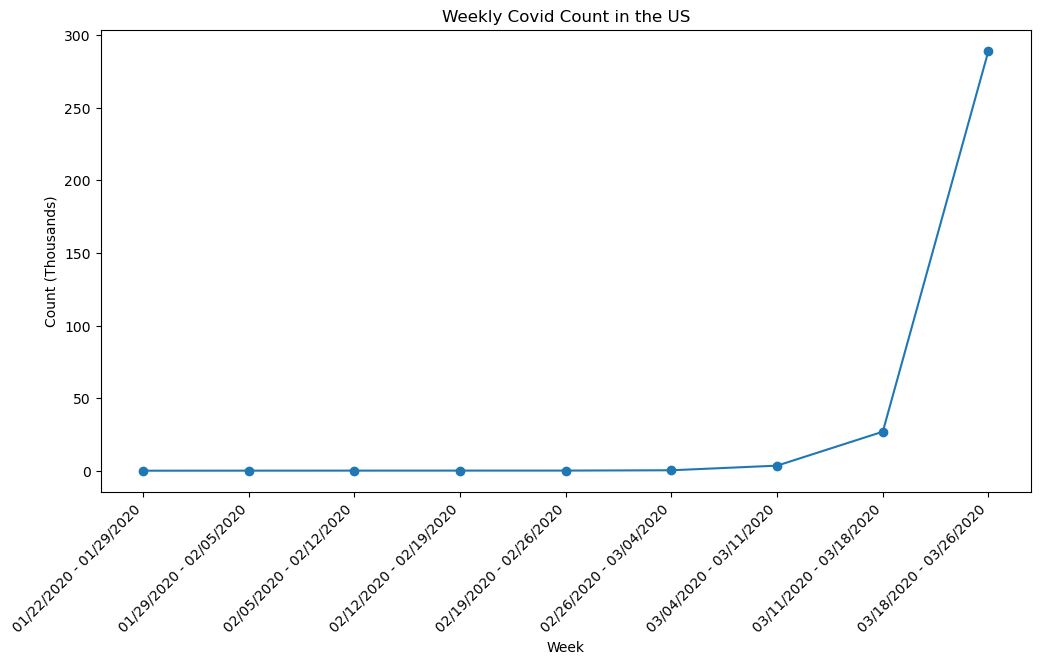

In [19]:
weekly_cum_sum = cum_sum[::7]
weekly_increase = [weekly_cum_sum[i] - weekly_cum_sum[i-1] for i in range(1, len(weekly_cum_sum))]

weekly_dates = pd.to_datetime(covid_df.columns.values[3:-2][::7]).strftime('%m/%d/%Y')
x_labels = [f"{weekly_dates[i]} - {weekly_dates[i+1]}" for i in range(len(weekly_dates) - 1)]

y = [x/1000 for x in weekly_increase]

plt.figure(figsize=(12, 6))
plt.plot(x_labels, y, marker='o', linestyle='-')
plt.title('Weekly Covid Count in the US')
plt.xlabel('Week')
plt.xticks(rotation=45, ha="right")
plt.ylabel('Count (Thousands)')

12. Please create a line plot that shows the changes of confirmed cases through time in top 10 states with the most confirmed cases by 3/29/2020. The y-axis of the plot should be in log. The 10 lines should be in different colors, with a legend specifying which color corresponds to which state.

In [20]:
grouped = covid_df.groupby('State')
date_cols = covid_df.columns[3:-2]
state_sum = grouped[date_cols].sum()
state_sum


,1/22/2020,1/23/2020,1/24/2020,1/25/2020,1/26/2020,1/27/2020,1/28/2020,1/29/2020,1/30/2020,1/31/2020,...,3/19/2020,3/20/2020,3/21/2020,3/23/2020,3/24/2020,3/25/2020,3/26/2020,3/27/2020,3/28/2020,3/29/2020
State,,,,,,,,,,,,,,,,,,,,,
Alabama,0,0,0,0,0,0,0,0,0,0,...,78,106,131,196,242,381,517,587,694,825
Alaska,0,0,0,0,0,0,0,0,0,0,...,8,11,13,30,34,41,56,58,85,102
American Samoa,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Arizona,0,0,0,0,1,1,1,1,1,1,...,45,68,104,235,326,401,508,665,773,919
Arkansas,0,0,0,0,0,0,0,0,0,0,...,62,100,122,192,219,280,335,381,409,426
California,0,0,0,0,2,2,2,2,2,3,...,1005,1243,1405,2108,2538,2998,3899,4657,5095,5852
Colorado,0,0,0,0,0,0,0,0,0,0,...,277,363,475,704,723,1021,1430,1433,1740,2307
Connecticut,0,0,0,0,0,0,0,0,0,0,...,159,194,194,415,618,875,1012,1291,1524,1993
Delaware,0,0,0,0,0,0,0,0,0,0,...,30,39,45,68,104,119,130,163,214,232


In [21]:
state_df.head(10) # now we know our top states

State
New York         287866
New Jersey        55188
California        35173
Washington        33104
Michigan          23549
Massachusetts     21323
Illinois          20969
Florida           20054
Louisiana         18735
Pennsylvania      14785
Name: cum_sum, dtype: int64

In [22]:
top_state = [
    'New York', 
    'New Jersey', 
    'California', 
    'Washington', 
    'Michigan', 
    'Massachusetts', 
    'Illinois', 
    'Florida', 
    'Louisiana', 
    'Pennsylvania'
] # this is taken from my states_df above

state_10 = state_sum[state_sum.index.isin(top_state)].sort_values(by='State') #alphabetical order
cum_sum_state = state_10.cumsum(axis=1)
cum_sum_state

,1/22/2020,1/23/2020,1/24/2020,1/25/2020,1/26/2020,1/27/2020,1/28/2020,1/29/2020,1/30/2020,1/31/2020,...,3/19/2020,3/20/2020,3/21/2020,3/23/2020,3/24/2020,3/25/2020,3/26/2020,3/27/2020,3/28/2020,3/29/2020
State,,,,,,,,,,,,,,,,,,,,,
California,0,0,0,0,2,4,6,8,10,13,...,5378,6621,8026,10134,12672,15670,19569,24226,29321,35173
Florida,0,0,0,0,0,0,0,0,0,0,...,1264,1704,2467,3694,5106,6788,9145,12045,15808,20054
Illinois,0,0,1,2,3,4,5,6,7,9,...,1295,1880,2633,3918,5455,7320,9858,12882,16373,20969
Louisiana,0,0,0,0,0,0,0,0,0,0,...,1177,1714,2477,3649,5037,6832,9136,11880,15195,18735
Massachusetts,0,0,0,0,0,0,0,0,0,0,...,1716,2129,2651,3429,4590,6431,8851,12095,16360,21323
Michigan,0,0,0,0,0,0,0,0,0,0,...,572,974,1514,2843,4636,6932,9777,13411,18061,23549
New Jersey,0,0,0,0,0,0,0,0,0,0,...,1839,2729,4056,6900,10575,14977,21853,30678,41802,55188
New York,0,0,0,0,0,0,0,0,0,0,...,8200,11452,15649,36533,62214,93055,130932,175808,228218,287866
Pennsylvania,0,0,0,0,0,0,0,0,0,0,...,754,1065,1464,2162,3108,4368,6163,8508,11353,14785


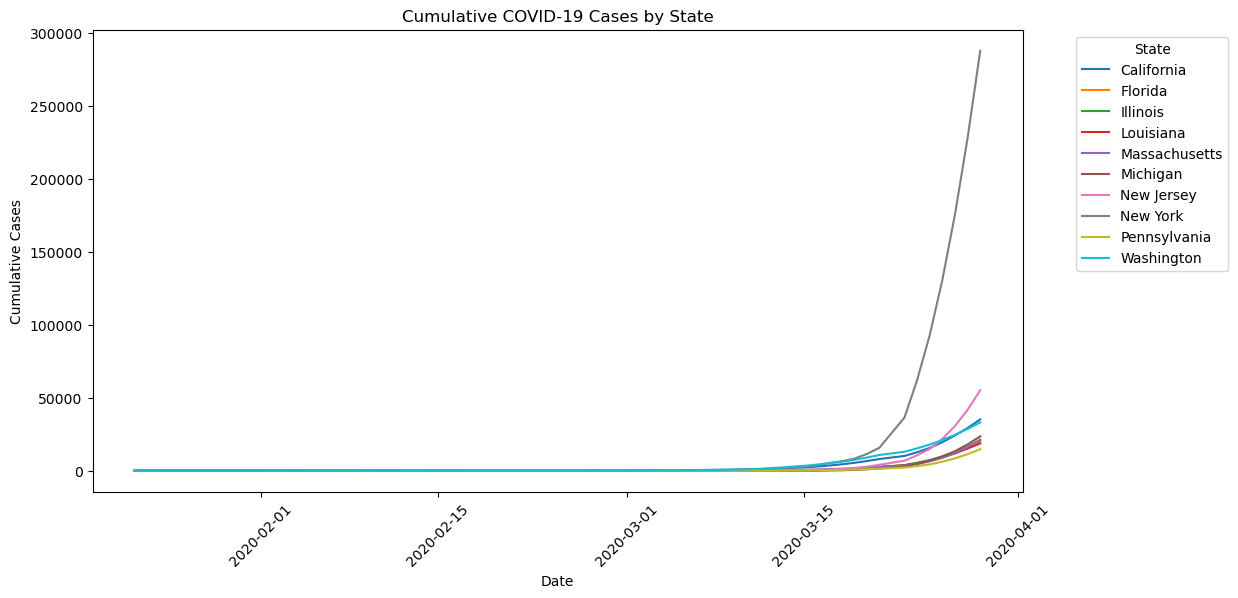

In [23]:
import seaborn as sns
plt.figure(figsize=(12, 6))
for state in cum_sum_state.index:
    plt.plot(date_columns, cum_sum_state.loc[state], label=state)

plt.xlabel("Date")
plt.ylabel("Cumulative Cases")
plt.title("Cumulative COVID-19 Cases by State")
plt.xticks(rotation=45)  # Rotate x-axis labels for readability
plt.legend(title="State", bbox_to_anchor=(1.05, 1), loc='upper left')  # Place legend outside plot
# sns.despine()

## 3. Patient Data

`patients.csv` contains a small sample of patients from the world, which has following columns.

* **id:** the ID of the patient in this dataset.
* **reporting date:** the date of reporting.
* **location:** the state or the province where the patient is in.
* **country:** the country where the patient is in.
* **gender:** the gender of the patient (male = 0, female = 1) if the data is reported
* **age:** the age of the patient if the data is reported


1. Load the data from `patients.csv`

In [24]:
pat_df = pd.read_csv(DATA_DIR + 'patients.csv')
pat_df.head()

,id,reporting date,location,country,gender,age
0,1,1/20/2020,"Shenzhen, Guangdong",China,0.0,66.0
1,2,1/20/2020,Shanghai,China,1.0,56.0
2,3,1/21/2020,Zhejiang,China,0.0,46.0
3,4,1/21/2020,Tianjin,China,1.0,60.0
4,5,1/21/2020,Tianjin,China,0.0,58.0


2. In the data set, the gender is coded as 0s and 1s (male=0, female=1). Please recode them as male and female in a new column. Also, please be aware that there are missing data in the dataset.

In [25]:
pat_df['new_gender'] = pat_df['gender'].map({0: 'Male', 1: 'Female'})
pat_df

,id,reporting date,location,country,gender,age,new_gender
0,1,1/20/2020,"Shenzhen, Guangdong",China,0.0,66.0,Male
1,2,1/20/2020,Shanghai,China,1.0,56.0,Female
2,3,1/21/2020,Zhejiang,China,0.0,46.0,Male
3,4,1/21/2020,Tianjin,China,1.0,60.0,Female
4,5,1/21/2020,Tianjin,China,0.0,58.0,Male
...,...,...,...,...,...,...,...
1080,1081,2/25/2020,Innsbruck,Austria,NaN,24.0,NaN
1081,1082,2/24/2020,Afghanistan,Afghanistan,NaN,35.0,NaN
1082,1083,2/26/2020,Algeria,Algeria,0.0,NaN,Male
1083,1084,2/25/2020,Croatia,Croatia,0.0,NaN,Male


3. What suggestions can you make for handling the missing gender data prior to performing any statistical analysis?

In [26]:
print(pat_df['new_gender'].isna().sum())
#since we do age analysis later, I don't want to just drop the NaN rows. I will impute them with the percentage found using value_counts.
num_males = 105 # i get this from 0.576 * 183
num_females = 78 # i get this from 0.424 * 183
impute_values = ['Male'] * num_males + ['Female'] * num_females
np.random.shuffle(impute_values)
pat_df.loc[pat_df['new_gender'].isna(), 'new_gender'] = impute_values
print(pat_df['new_gender'].isna().sum())

183
0


Around 17% of the gender column is NaN. Dropping them would still leave us with a considerable portion of our dataset. Or we could randomly fill half with male and half with female to keep a similar gender ratio. This adds noise to our data. Or we could randomly fill it with the same proportion of male to female in the dataset. For example, if currently there are 60% females then 60% of the missing data would also be filled with females. This at least keeps the same gender ratio we have for the non NaN data. 

---

In the following parts, we will ask you to do some basic statistical analysis. For the tasks below, the main statistic model we will use is [goodness of fit](https://en.wikipedia.org/wiki/Goodness_of_fit), which will let you know how well the data we observed (e.g. the patient data here) fit to the distribution of the general population.

For example, if we assume that we are in a world where people mutually exclusively like sparkling water, tea, or coffee. We also know that in that world, 60% of people from country A, 30% from country B, and 10% from country C. Then naturally, if the country of origin doesn't affect which type of drink people like, when having a representative sample of the population, we should expect that for all types of drinks, the composition of people who like the drink should be the same as the general population (i.e. 6:3:1 in terms of the origin country), which is what we called a [null hypothesis](https://en.wikipedia.org/wiki/Null_hypothesis). However, if we observe that the compostion is *very* different from the composition of general population, then it indicates that there might be a correlation between where people are from and what types of drink they like. The more the observation data deviates from the expectation, the more likely that there is a correlation between them.

We often use [p-value](https://en.wikipedia.org/wiki/P-value) to evaluate whether the deviance is big enough to be considered as a correlation instead of a coincidence. In most cases, we would say that if p-value < 0.05, then the correlation is [statistically significant](https://en.wikipedia.org/wiki/Statistical_significance). To calculate a p-value, one needs to decide which statistical test to use, which is related to [the type of data](https://en.wikipedia.org/wiki/Statistical_data_type) one is dealing with. For example, in the above example, both dependent variable (i.e. types of drink) and independent variable (i.e. the origin country of the person) are categorical, in which case a Chi-square test should be used (read the links for more information).

---

4. What is the percentage of each gender in the dataset? 
We want to understand if there is a significant difference in gender among the covid patient data available to us. To conduct such a test, please write down your null/alternative hypothesis.
Then provide a justification of which significant test should be used, the assumptions you made for using the test, and provide a p-value.

In [27]:
print(pat_df['new_gender'].value_counts()/len(pat_df))
print(pat_df['new_gender'].value_counts())

new_gender
Male      0.576037
Female    0.423963
Name: count, dtype: float64
new_gender
Male      625
Female    460
Name: count, dtype: int64


Within the existing non null data, 57.6% are male, 42.4% are female. To test whether there is a significant difference in gender among the covid patient data our null hypothesis should be proportion of each gender = 50% (p_m = 0.5). That would mean the expected number of males and females are 542.5 each. The alternate hypothesis is p_m is not 0.5, or p_m > 0.5. I would choose p_m > 0.5 because it seems from our available data that there are more males than females. Thus it would be a one tailed z-test because we probably know the standard deviation of distribution of gender within the population. We will have an alpha significance value of a = 0.05. 

In [28]:
import scipy.stats as stats
n = len(pat_df) 
x_males = 625  
p_0 = 0.5  

p_hat = x_males / n

# Z-test statistic calculation
z_score = (p_hat - p_0) / np.sqrt((p_0 * (1 - p_0)) / n)

# Calculate p-value (two-tailed test)
p_value = 1 - stats.norm.cdf(z_score)

# Output results
print(f"Z-score: {z_score}")
print(f"P-value: {p_value}")


Z-score: 5.009208110931056
P-value: 2.7327224405571116e-07


It's significant! This means that we reject the null and conclude that the proportion of males is greater for covid cases than in the population. 

5. For numerical data such as age, provide a visualization that illustrates a good understanding of its distribution in the patient data with an explanation for your choice of plot.

/var/folders/xm/ynhl86150vlb4bv7dtln_t0h0000gn/T/ipykernel_8495/400261796.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=pat_df['age'], shade=True)


Text(0, 0.5, 'Density')

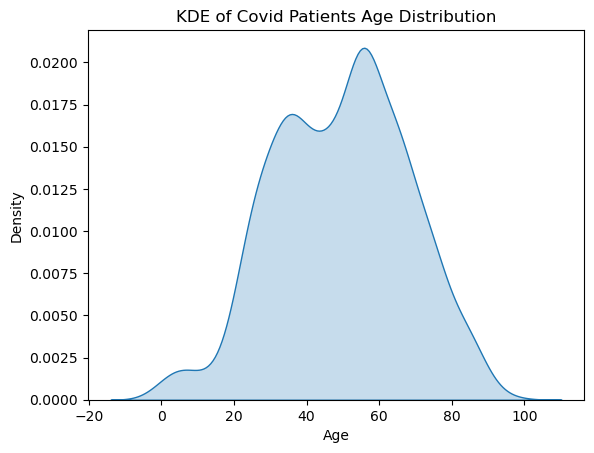

In [29]:
sns.kdeplot(x=pat_df['age'], shade=True)
plt.title('KDE of Covid Patients Age Distribution')
plt.xlabel('Age')
plt.ylabel('Density')

I chose a KDE because it is simple/easy to understand and appropriate for continuous numeric data. Percentage gives us a better understanding of the probability distribution than frequency does. 

The world age structure data in 2018 is shown as below.
    * 0-14 years: 25.29%
    * 15-24 years: 15.77%
    * 25-54 years: 41.03%
    * 55-64 years: 8.84%
    * 65 years and over: 9.06%

Use this insight for the rest of the exercise.

6. Please plot the age distribution by discretizing the available data into bins used in the provided age structure.

Text(0, 0.5, 'Density')

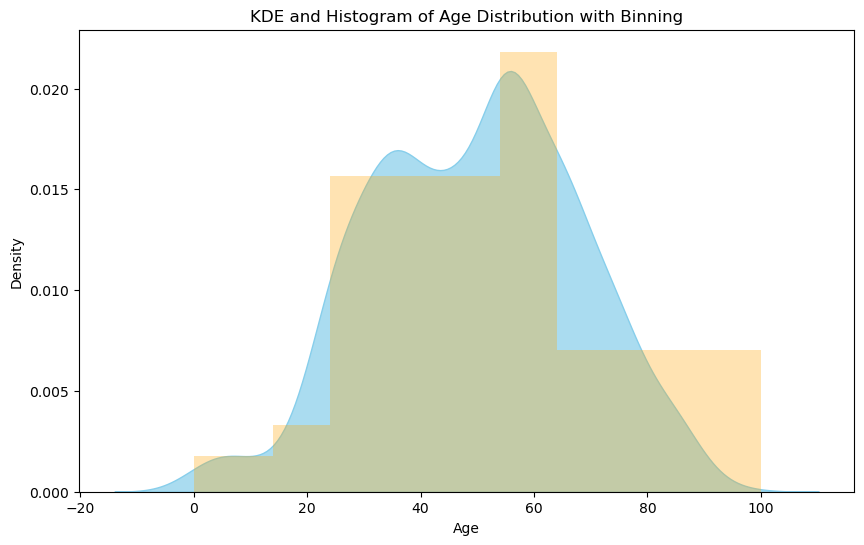

In [30]:
bins = [0, 14, 24, 54, 64, 100]

# Plotting KDE with custom bandwidth
plt.figure(figsize=(10, 6))

# KDE plot with bandwidth adjustment
sns.kdeplot(pat_df['age'], fill=True, color="skyblue", alpha=0.7) 

# Overlay the histogram with the same bins for reference
plt.hist(pat_df['age'], bins=bins, alpha=0.3, color="orange", density=True)

# Set the title and labels
plt.title('KDE and Histogram of Age Distribution with Binning')
plt.xlabel('Age')
plt.ylabel('Density')

7. Conduct a test to see whether the age distribution of patients in this dataset significantly deviates from the age structure of general population. Provide the null/alternative hypothesis, the test you are using, the assumptions of the data distribution, and the p-value.\
Also specify how you have handled the missing data for this specific question.

The null hypothesis is proportion of the age groups in the data set are the same proportion as the population. The alternate hypothesis is that they are different. Thus, this is a chi-squared test for goodness of fit. Using the chi-squared test means that each group must have at least 5 observations (they do). The p-value for our test is 0.05. Missing data will be imputed with the median age. 

In [31]:
#dealing with missing data
print(pat_df['age'].isna().sum())
pat_df['age'] = pat_df['age'].fillna(pat_df['age'].median())

242


In [32]:
#getting counts 
labels = ["0-14", "15-24", "25-54", "55-64", "65+"] 
pat_df["age_group_bins"] = pd.cut(pat_df["age"], bins=bins, labels=labels, right=True)
observed_counts = pat_df["age_group_bins"].value_counts().sort_index().values
# population_proportions = np.array([0.2529, 0.1577, 0.4103, 0.0884, 0.0906])
# expected_counts = 1085 * population_proportions 

# ran the above code, it didn't add up to 1085 exactly due to rounding so I've taken the liberty to do that here
expected_counts = np.array([274, 171, 445,  96 ,  99])

In [33]:
import scipy.stats as stats

chi2_stat, p_value = stats.chisquare(observed_counts, expected_counts)

# Print results
print(f"Chi-Squared Statistic: {chi2_stat}")
print(f"p-value: {p_value}")

Chi-Squared Statistic: 613.6795890755858
p-value: 1.6962707152495943e-131


Our chi-squared test was significant because the p-value is very close to 0. Thus, we can reject the null hypothesis and conclude that the distribution of age within covid cases is different from distribution of age in population. 